In [1]:
from glob import glob
from itertools import product

import pandas as pd
from upsetplot import plot
from utils import add_temp_errors, extract_digits_from_answers, merge_with_indomain_year_only

In [2]:
df = pd.read_csv(
    "../../models/predictions/gpt4/fewshot_with_reasoning/indomain_eval_gpt_4_few_shot_with_reasoning_single.csv"
)
df = (
    df.pipe(merge_with_indomain_year_only)
    .pipe(extract_digits_from_answers)
    .query("answer_digits.str.len()==1 and predicted_answer_digits.str.len()==1")
    .pipe(add_temp_errors)
)

In [3]:
df.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits,err,rel_err,abs_err,abs_per_err,log_err
0,How many years did Art Carney as actor since 1...,54 Years,2,54 years,54 years && Art Carney was active from 1939 to...,54 years,54,54,0,0.000000,0,0.000000,0.000000
1,How many total years was Art Carney married to...,28 years,2,45 years,45 years && Art Carney was married to Jean Mye...,45 years,28,45,17,0.607143,17,60.714286,0.461346
2,How many years before he died was Art Carney m...,23,2,23 years,23 years && Art Carney remarried his first wif...,23 years,23,23,0,0.000000,0,0.000000,0.000000
3,How old was Art Carney when he first got divor...,47,2,46 years old,46 years old && Art was born in 1918 and got d...,46 years old,47,46,-1,-0.021277,1,2.127660,-0.021053
4,How many years ago did Art Carney was died?,19 Years ago,2,19 years ago,"19 years ago && Art Carney died in 2003, and c...",19 years ago,19,19,0,0.000000,0,0.000000,0.000000


<Axes: xlabel='answer_digits', ylabel='predicted_answer_digits'>

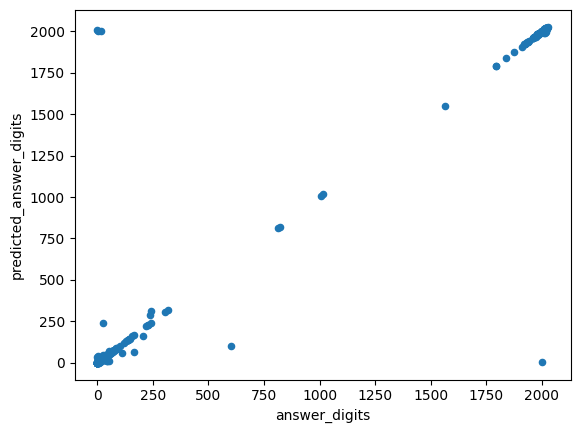

In [4]:
df.loc[:, ["answer_digits", "predicted_answer_digits"]].sort_values(by="answer_digits").plot(
    kind="scatter", x="answer_digits", y="predicted_answer_digits"
)

<Axes: xlabel='answer_digits', ylabel='predicted_answer_digits'>

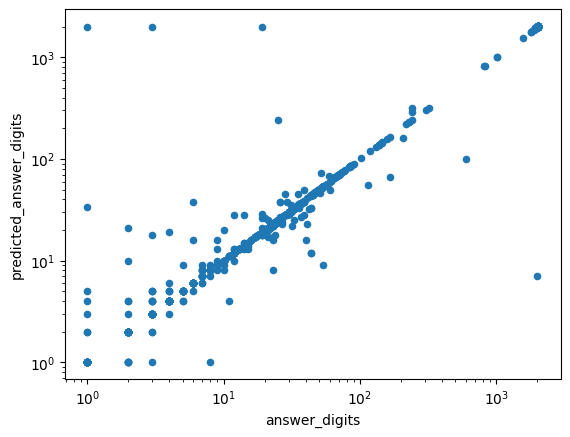

In [5]:
df.loc[:, ["answer_digits", "predicted_answer_digits"]].sort_values(by="answer_digits").plot(
    kind="scatter", x="answer_digits", y="predicted_answer_digits", logx=True, logy=True
)

<Axes: xlabel='Absolute error in years', ylabel='Temporal error per QA-pair'>

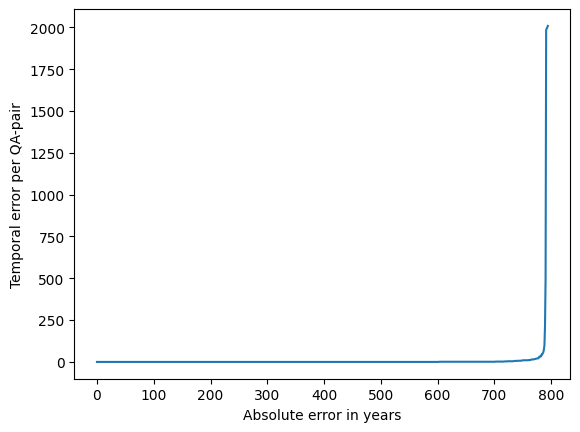

In [ ]:
df.loc[:, ["answer_digits", "predicted_answer_digits"]].assign(
    error=lambda x: (x["predicted_answer_digits"] - x["answer_digits"]).abs()
).sort_values(by="error").loc[:, "error"].reset_index(drop=True).plot(
    kind="line", xlabel="Absolute error in years", ylabel="Temporal error per QA-pair"
);

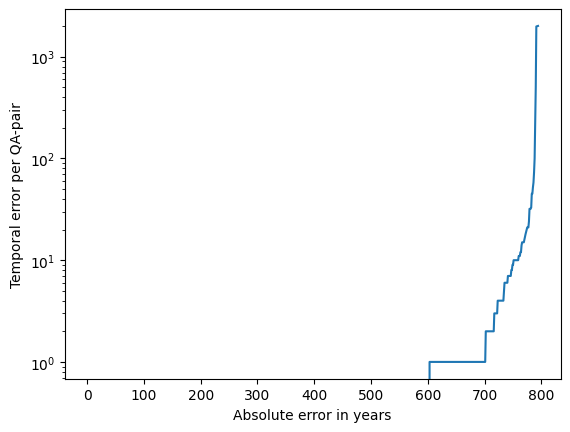

In [ ]:
df.loc[:, ["answer_digits", "predicted_answer_digits"]].assign(
    error=lambda x: (x["predicted_answer_digits"] - x["answer_digits"]).abs()
).sort_values(by="error").loc[:, "error"].reset_index(drop=True).plot(
    kind="line",
    xlabel="Absolute error in years",
    ylabel="Temporal error per QA-pair",
    logy=True,
);

## Explore error types

In [6]:
def inline_render_html(html_str):
    return f'<div style="border: 1px solid #ddd; padding: 5px;">{html_str}</div>'


def html_render_df(df, html_col="table"):
    return df.style.format({html_col: inline_render_html}).set_properties(
        subset=["table"], **{"text-align": "left"}
    )


In [7]:
wrongs_df = df.query("answer_digits != predicted_answer_digits").loc[
    :, ["question", "answer", "predicted_answer_old", "table_id"]
]

In [8]:
id_to_table = {}
for path in glob("../../data/maindata/tables/html/*.html"):
    file_name = path.split("/")[-1]
    table_id = file_name.split(".")[0]
    with open(path) as f:
        html = f.read()
    id_to_table[int(table_id)] = html

In [9]:
wrongs_df.loc[:, "table"] = [id_to_table[id_] for id_ in wrongs_df.loc[:, "table_id"]]

In [10]:
wrongs_df.head()

,question,answer,predicted_answer_old,table_id,table
1,How many total years was Art Carney married to...,28 years,45 years && Art Carney was married to Jean Mye...,2,"<html><body><table class=""infobox biography vc..."
3,How old was Art Carney when he first got divor...,47,46 years old && Art was born in 1918 and got d...,2,"<html><body><table class=""infobox biography vc..."
13,How many years long was Dwayne Johnson's profe...,23,17 years && His wrestling career spanned from ...,7,"<html><body><table class=""infobox biography vc..."
14,When was the last time that Dwayne Johnson com...,2019,2013 && He competed professionally in wrestlin...,7,"<html><body><table class=""infobox biography vc..."
17,How many years did Dwayne Johnson was in wrest...,23 Years,16 years && His wrestling career spanned from ...,7,"<html><body><table class=""infobox biography vc..."


In [11]:
#wrongs_df.to_csv("data/notebook_output/05a_gpt4_indomain_wrong_pred_for_labeling.csv")

In [12]:
labeled_wrongs = pd.read_json(
    "./data/05a_gpt4_indomain_wrong_pred_labeled.json", orient="records"
).loc[:, ["annotations", "data"]]
labeled_wrongs.head()

,annotations,data
0,"[{'id': 1378, 'completed_by': 1, 'result': [{'...","{'Unnamed: 0': 1, 'question': 'How many total ..."
1,"[{'id': 1379, 'completed_by': 1, 'result': [{'...","{'Unnamed: 0': 3, 'question': 'How old was Art..."
2,"[{'id': 1380, 'completed_by': 1, 'result': [{'...","{'Unnamed: 0': 13, 'question': 'How many years..."
3,"[{'id': 1381, 'completed_by': 1, 'result': [{'...","{'Unnamed: 0': 14, 'question': 'When was the l..."
4,"[{'id': 1382, 'completed_by': 1, 'result': [{'...","{'Unnamed: 0': 17, 'question': 'How many years..."


In [13]:
labeled_wrongs = labeled_wrongs.drop(30)  # This row does not have any labeled data

In [14]:
labeled_wrongs.loc[:, "annotations"].apply(lambda x: x[0]["result"])[0]

[{'value': {'text': ['no']},
  'id': 'rNksQ4NW1m',
  'from_name': 'gold_assess',
  'to_name': 'gold',
  'type': 'textarea',
  'origin': 'manual'},
 {'value': {'text': ['yes']},
  'id': 'KnDuvwkbnO',
  'from_name': 'reasoning_assess',
  'to_name': 'question',
  'type': 'textarea',
  'origin': 'manual'},
 {'value': {'text': ['no']},
  'id': 'Auzoa48jVX',
  'from_name': 'arithmetic_assess',
  'to_name': 'question',
  'type': 'textarea',
  'origin': 'manual'}]

In [15]:
labeled_wrongs.loc[:, "annotations"].apply(lambda x: x[0]["result"]).apply(len)

0      3
1      3
2      4
3      3
4      3
      ..
187    4
188    4
189    3
190    3
191    3
Name: annotations, Length: 191, dtype: int64

In [16]:
labeled_wrongs = labeled_wrongs.assign(
    question=lambda x: x["data"].apply(lambda y: y["question"]),
    answer=lambda x: x["data"].apply(lambda y: y["answer"]),
    predicted_answer_old=lambda x: x["data"].apply(lambda y: y["predicted_answer_old"]),
    is_gold_correct=lambda x: x["annotations"].apply(
        lambda y: y[0]["result"][0]["value"]["text"][0]
    ),
    is_reasoning_correct=lambda x: x["annotations"].apply(
        lambda y: y[0]["result"][1]["value"]["text"][0]
    ),
    is_arithmetic_correct=lambda x: x["annotations"].apply(
        lambda y: y[0]["result"][2]["value"]["text"][0]
    ),
).drop(columns=["annotations", "data"])
labeled_wrongs.head()

,question,answer,predicted_answer_old,is_gold_correct,is_reasoning_correct,is_arithmetic_correct
0,How many total years was Art Carney married to...,28 years,45 years && Art Carney was married to Jean Mye...,no,yes,no
1,How old was Art Carney when he first got divor...,47,46 years old && Art was born in 1918 and got d...,yes,yes,no
2,How many years long was Dwayne Johnson's profe...,23,17 years && His wrestling career spanned from ...,yes,yes,no
3,When was the last time that Dwayne Johnson com...,2019,2013 && He competed professionally in wrestlin...,yes,no,-
4,How many years did Dwayne Johnson was in wrest...,23 Years,16 years && His wrestling career spanned from ...,yes,yes,no


In [17]:
upset_df = labeled_wrongs.query("is_arithmetic_correct != '-'").replace(
    {
        "zes": "yes",
    }
).replace({"yes": True, "no": False, "wrong": False}).groupby(
    ["is_gold_correct", "is_reasoning_correct", "is_arithmetic_correct"]
).size()
upset_df.sort_values()

/var/folders/9d/qnh66b_96jq1whwx64rh7yq40000gn/T/ipykernel_59687/520921483.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace({"yes": True, "no": False, "wrong": False}).groupby(


is_gold_correct  is_reasoning_correct  is_arithmetic_correct
False            False                 False                     2
                                       True                      2
                 True                  False                     4
True             False                 False                    12
                 True                  True                     14
                 False                 True                     15
False            True                  True                     31
True             True                  False                    83
dtype: int64

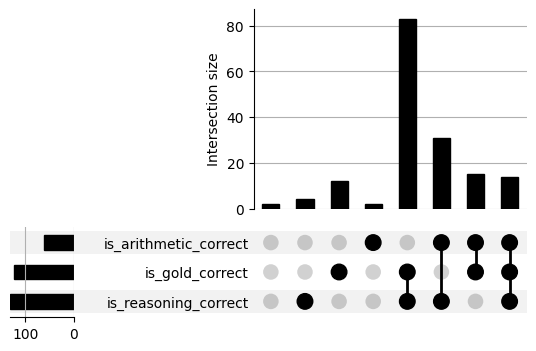

In [18]:
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
plot(upset_df.sort_values());


## One year error statistically very likely

In [19]:
end = pd.date_range(start="2012-01-01", end="2012-12-31")
start = pd.date_range(start="1990-01-01", end="1990-12-31")

In [20]:
list(product(["Jan", "Feb"], ["Jan", "Feb", "Mar"]))

[('Jan', 'Jan'),
 ('Jan', 'Feb'),
 ('Jan', 'Mar'),
 ('Feb', 'Jan'),
 ('Feb', 'Feb'),
 ('Feb', 'Mar')]

In [28]:
diffs = []
for start_date, end_date in product(start, end):
    years_elapsed = (
        end_date.year
        - start_date.year
        - ((end_date.month, end_date.day) < (start_date.month, start_date.day))
    )

    diffs.append(years_elapsed)


In [29]:
(pd.Series(diffs).value_counts(normalize=True) * 100).round(2)

22    50.04
21    49.96
Name: proportion, dtype: float64

In [30]:
diffs = []
for start_date, end_date in product(start, end):
    years_elapsed = (
        end_date.year
        - start_date.year
        - ((end_date.month) < (start_date.month))
    )
    diffs.append(years_elapsed)
(pd.Series(diffs).value_counts(normalize=True) * 100).round(2)

22    54.07
21    45.93
Name: proportion, dtype: float64